# 🤖 JobAI

JobAI est un système de recherche d'offres d'emploi permettant
de rechercher des offres à partir d'une requête en langage naturel.

Le système combine :
- l'analyse des critères de recherche ;
- la recherche sémantique ;
- la correspondance des compétences ;
- un score hybride.

## 1. Importation des bibliothèques


In [8]:
# Import pandas pour manipuler et analyser les données sous forme de tableaux
import pandas as pd

# Import numpy pour effectuer des calculs numériques
import numpy as np

# Import matplotlib pour créer des graphiques
import matplotlib.pyplot as plt

# Import seaborn pour créer des visualisations statistiques plus facilement
import seaborn as sns


# Vérification : on s'assure que notre environnement fonctionne correctement
print("JobAI 🚀")
print("Environnement Python opérationnel !")

JobAI 🚀
Environnement Python opérationnel !


2. Chargement et préparation des données

In [9]:
# Chemin vers notre fichier CSV contenant les offres d'emploi brutes
chemin_fichier = "../data/raw/offres_emploi.csv"

# Lecture du fichier CSV et création du DataFrame
df = pd.read_csv(r"C:\Users\nabou\OneDrive\Documents\M2 DS\JobAI\data\raw\offres_emploi.csv")

# Affichage d'un message pour vérifier que le chargement a fonctionné
print("Dataset chargé avec succès !")

Dataset chargé avec succès !


In [10]:
# Affiche les 5 premières lignes du DataFrame
# Cela permet de vérifier que les données ont été correctement chargées
# et de voir concrètement la structure de nos offres.
df.head()

,job_id,title,company,location,contract,education,skills,salary,publication_date,description,url
0,1,Data Analyst,Entreprise A,Lille,Alternance,Bac+4/5,Python;SQL;Power BI;Excel,NaN,2026-09-20,"Analyse des données, création de tableaux de b...",https://example.com/offre-1
1,2,Data Scientist,Entreprise B,Paris,Alternance,Bac+5,Python;Machine Learning;SQL;Pandas,1400.0,2026-09-19,Développement de modèles de machine learning e...,https://example.com/offre-2
2,3,BI Analyst,Entreprise C,Lille,Alternance,Bac+4/5,SQL;Power BI;Excel;DAX,NaN,2026-09-18,Production de rapports et de tableaux de bord ...,https://example.com/offre-3
3,4,Data Analyst,Entreprise D,Lyon,Stage,Bac+4/5,Python;SQL;Tableau,1200.0,2026-09-17,"Préparation des données, analyses exploratoire...",https://example.com/offre-4
4,5,Data Engineer,Entreprise E,Paris,Alternance,Bac+4/5,Python;SQL;ETL;Spark,1500.0,2026-09-16,Participation à la construction et à la mainte...,https://example.com/offre-5


In [11]:
# Affiche le nombre de lignes et de colonnes du DataFrame
# Le résultat est de la forme : (nombre_de_lignes, nombre_de_colonnes)
df.shape

(10, 11)

In [12]:
# Affiche des informations détaillées sur le DataFrame :
# - nombre de lignes
# - nom des colonnes
# - type de chaque variable
# - nombre de valeurs non nulles
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   job_id            10 non-null     int64  
 1   title             10 non-null     str    
 2   company           10 non-null     str    
 3   location          10 non-null     str    
 4   contract          10 non-null     str    
 5   education         10 non-null     str    
 6   skills            10 non-null     str    
 7   salary            6 non-null      float64
 8   publication_date  10 non-null     str    
 9   description       10 non-null     str    
 10  url               10 non-null     str    
dtypes: float64(1), int64(1), str(9)
memory usage: 2.8 KB


In [13]:
# Compte le nombre de valeurs manquantes pour chaque colonne
# Cela permet d'identifier les informations qui ne sont pas renseignées.
df.isna().sum()

job_id              0
title               0
company             0
location            0
contract            0
education           0
skills              0
salary              4
publication_date    0
description         0
url                 0
dtype: int64

In [14]:
# Affiche les valeurs uniques de la colonne publication_date
# Cela permet de vérifier le format actuel des dates avant de les transformer.
df["publication_date"].unique()

<ArrowStringArray>
['2026-09-20', '2026-09-19', '2026-09-18', '2026-09-17', '2026-09-16',
 '2026-09-15', '2026-09-14', '2026-09-13', '2026-09-12', '2026-09-11']
Length: 10, dtype: str

In [15]:
# Affiche le type de données actuel de la colonne publication_date
# On s'attend actuellement à obtenir : object
df["publication_date"].dtype

<StringDtype(na_value=nan)>

In [16]:
# Convertit la colonne publication_date du format texte
# vers un véritable format de date reconnu par Pandas.
df["publication_date"] = pd.to_datetime(df["publication_date"])

# Vérifie le nouveau type de données de la colonne.
df["publication_date"].dtype

dtype('<M8[us]')

In [17]:
# Sélectionne uniquement les offres pour lesquelles le salaire n'est pas renseigné.
# Cela nous permet d'examiner les lignes concernées avant de choisir
# une stratégie de traitement des valeurs manquantes.
df[df["salary"].isna()]

,job_id,title,company,location,contract,education,skills,salary,publication_date,description,url
0,1,Data Analyst,Entreprise A,Lille,Alternance,Bac+4/5,Python;SQL;Power BI;Excel,NaN,2026-09-20,"Analyse des données, création de tableaux de b...",https://example.com/offre-1
2,3,BI Analyst,Entreprise C,Lille,Alternance,Bac+4/5,SQL;Power BI;Excel;DAX,NaN,2026-09-18,Production de rapports et de tableaux de bord ...,https://example.com/offre-3
5,6,Data Analyst,Entreprise F,Lille,Alternance,Bac+3/5,Excel;SQL;Power BI;Python,NaN,2026-09-15,Analyse des performances et création de report...,https://example.com/offre-6
7,8,Analyste BI,Entreprise H,Lille,Alternance,Bac+4,SQL;Power BI;Excel,NaN,2026-09-13,Conception de tableaux de bord et analyse des ...,https://example.com/offre-8


In [18]:
# Création d'une variable indiquant si le salaire est renseigné.
# True  = le salaire est disponible
# False = le salaire n'est pas renseigné

df["salary_available"] = df["salary"].notna()

# Affiche les premières lignes pour vérifier le résultat.
df[["job_id", "salary", "salary_available"]]

,job_id,salary,salary_available
0,1,NaN,False
1,2,1400.0,True
2,3,NaN,False
3,4,1200.0,True
4,5,1500.0,True
5,6,NaN,False
6,7,1300.0,True
7,8,NaN,False
8,9,1450.0,True
9,10,1550.0,True


In [19]:
# Affiche les compétences associées à chaque offre.
# Cela permet d'observer la structure actuelle de la colonne skills
# avant de commencer sa transformation.
df[["job_id", "title", "skills"]]

,job_id,title,skills
0,1,Data Analyst,Python;SQL;Power BI;Excel
1,2,Data Scientist,Python;Machine Learning;SQL;Pandas
2,3,BI Analyst,SQL;Power BI;Excel;DAX
3,4,Data Analyst,Python;SQL;Tableau
4,5,Data Engineer,Python;SQL;ETL;Spark
5,6,Data Analyst,Excel;SQL;Power BI;Python
6,7,Data Scientist,Python;Scikit-learn;Machine Learning;SQL
7,8,Analyste BI,SQL;Power BI;Excel
8,9,Data Analyst,Python;SQL;Pandas;Excel
9,10,Data Scientist,Python;NLP;Machine Learning;SQL


In [20]:
# Affiche le type de données de la colonne skills.
# Nous voulons vérifier que Pandas considère actuellement
# chaque ensemble de compétences comme une chaîne de caractères.
df["skills"].dtype

<StringDtype(na_value=nan)>

In [21]:
# Transforme la chaîne de compétences en liste.
# Le séparateur ";" permet de distinguer chaque compétence.
df["skills_list"] = df["skills"].str.split(";")

# Affiche les anciennes et nouvelles colonnes
# pour vérifier que la transformation s'est bien effectuée.
df[["job_id", "skills", "skills_list"]]

,job_id,skills,skills_list
0,1,Python;SQL;Power BI;Excel,"[Python, SQL, Power BI, Excel]"
1,2,Python;Machine Learning;SQL;Pandas,"[Python, Machine Learning, SQL, Pandas]"
2,3,SQL;Power BI;Excel;DAX,"[SQL, Power BI, Excel, DAX]"
3,4,Python;SQL;Tableau,"[Python, SQL, Tableau]"
4,5,Python;SQL;ETL;Spark,"[Python, SQL, ETL, Spark]"
5,6,Excel;SQL;Power BI;Python,"[Excel, SQL, Power BI, Python]"
6,7,Python;Scikit-learn;Machine Learning;SQL,"[Python, Scikit-learn, Machine Learning, SQL]"
7,8,SQL;Power BI;Excel,"[SQL, Power BI, Excel]"
8,9,Python;SQL;Pandas;Excel,"[Python, SQL, Pandas, Excel]"
9,10,Python;NLP;Machine Learning;SQL,"[Python, NLP, Machine Learning, SQL]"


In [22]:
# Transforme chaque élément de la liste skills_list
# en une ligne distincte.
#
# Une offre qui possède 4 compétences aura donc 4 lignes.
df_skills = df.explode("skills_list")

# Renomme la colonne pour avoir un nom plus simple
# et plus explicite dans notre nouveau DataFrame.
df_skills = df_skills.rename(columns={"skills_list": "skill"})

# Affiche les premières lignes pour vérifier le résultat.
df_skills[["job_id", "title", "skill"]].head(15)

,job_id,title,skill
0,1,Data Analyst,Python
0,1,Data Analyst,SQL
0,1,Data Analyst,Power BI
0,1,Data Analyst,Excel
1,2,Data Scientist,Python
1,2,Data Scientist,Machine Learning
1,2,Data Scientist,SQL
1,2,Data Scientist,Pandas
2,3,BI Analyst,SQL
2,3,BI Analyst,Power BI


In [23]:
# Compte le nombre d'offres associées à chaque compétence.
# value_counts() compte le nombre d'apparitions de chaque valeur
# dans la colonne "skill".
skills_counts = df_skills["skill"].value_counts()

# Affiche les compétences de la plus fréquente à la moins fréquente.
skills_counts

skill
SQL                 10
Python               8
Excel                5
Power BI             4
Machine Learning     3
Pandas               2
DAX                  1
Tableau              1
ETL                  1
Spark                1
Scikit-learn         1
NLP                  1
Name: count, dtype: int64

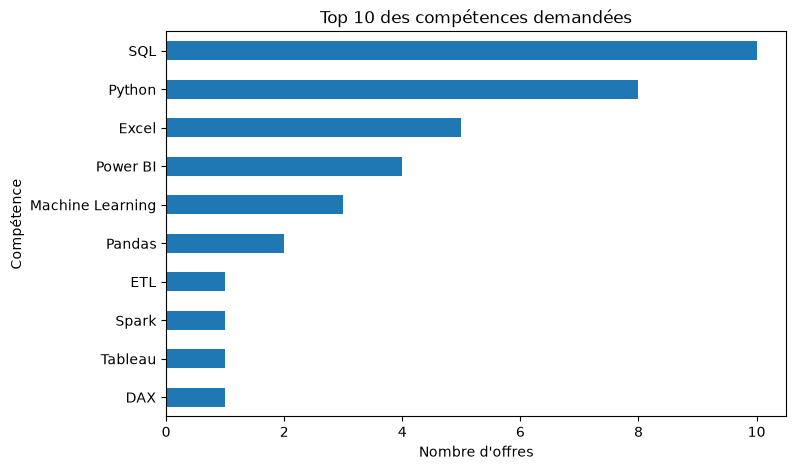

In [24]:
# Sélectionne les 10 compétences les plus fréquentes
# afin de rendre le graphique lisible.
top_skills = skills_counts.head(10)

# Crée un graphique en barres horizontales.
top_skills.sort_values().plot(
    kind="barh",
    figsize=(8, 5),
    title="Top 10 des compétences demandées"
)

# Ajoute un titre à l'axe horizontal.
plt.xlabel("Nombre d'offres")

# Ajoute un titre à l'axe vertical.
plt.ylabel("Compétence")

# Affiche le graphique.
plt.show()

In [25]:
# Compte le nombre d'apparitions de chaque compétence
# pour chaque type de poste.
skills_by_job = (
    df_skills
    .groupby(["title", "skill"])
    .size()
    .reset_index(name="count")
)

# Affiche le résultat obtenu.
skills_by_job

,title,skill,count
0,Analyste BI,Excel,1
1,Analyste BI,Power BI,1
2,Analyste BI,SQL,1
3,BI Analyst,DAX,1
4,BI Analyst,Excel,1
5,BI Analyst,Power BI,1
6,BI Analyst,SQL,1
7,Data Analyst,Excel,3
8,Data Analyst,Pandas,1
9,Data Analyst,Power BI,2


 3. Exploration des offres d'emploi

In [26]:
# Compte le nombre de compétences différentes associées à chaque métier.
# nunique() compte le nombre de valeurs distinctes dans la colonne "skill".
skills_diversity = (
    df_skills
    .groupby("title")["skill"]
    .nunique()
    .sort_values(ascending=False)
)

# Affiche le nombre de compétences différentes pour chaque métier.
skills_diversity

title
Data Analyst      6
Data Scientist    6
BI Analyst        4
Data Engineer     4
Analyste BI       3
Name: skill, dtype: int64

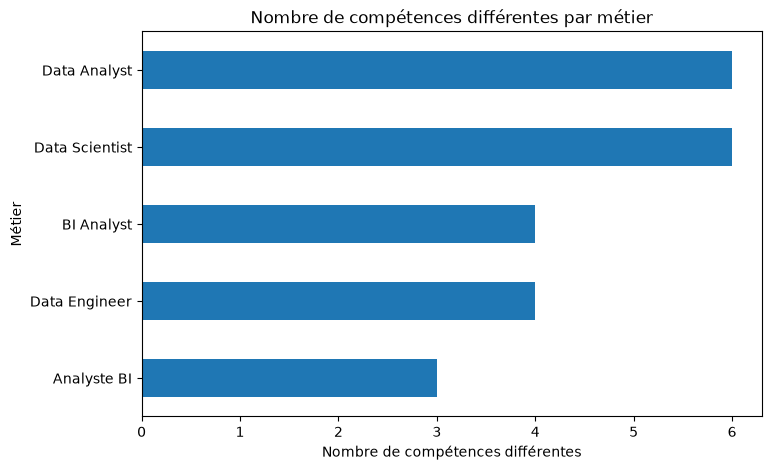

In [27]:
# Création d'un graphique montrant le nombre de compétences
# différentes associées à chaque métier.
skills_diversity.sort_values().plot(
    kind="barh",
    figsize=(8, 5),
    title="Nombre de compétences différentes par métier"
)

# Nom de l'axe horizontal.
plt.xlabel("Nombre de compétences différentes")

# Nom de l'axe vertical.
plt.ylabel("Métier")

# Affiche le graphique.
plt.show()

In [28]:
# Recherche les offres dont le titre contient "Data Analyst".
# str.contains() permet de vérifier si une chaîne de caractères
# contient le texte recherché.
#
# case=False permet d'ignorer les différences entre majuscules
# et minuscules.
# na=False évite les problèmes si certaines offres n'ont pas de titre.

offres_data_analyst = df[
    df["title"].str.contains("Data Analyst", case=False, na=False)
]

# Affiche les informations principales des offres trouvées.
offres_data_analyst[["job_id", "title", "company", "location", "contract"]]

,job_id,title,company,location,contract
0,1,Data Analyst,Entreprise A,Lille,Alternance
3,4,Data Analyst,Entreprise D,Lyon,Stage
5,6,Data Analyst,Entreprise F,Lille,Alternance
8,9,Data Analyst,Entreprise I,Paris,Alternance


In [29]:
# Recherche les offres de Data Analyst situées à Lille.
# Les deux conditions doivent être vraies pour qu'une offre soit conservée.

offres_data_analyst_lille = df[
    (df["title"].str.contains("Data Analyst", case=False, na=False))
    & (df["location"].str.contains("Lille", case=False, na=False))
]

# Affiche les offres correspondantes.
offres_data_analyst_lille[
    ["job_id", "title", "company", "location", "contract"]
]

,job_id,title,company,location,contract
0,1,Data Analyst,Entreprise A,Lille,Alternance
5,6,Data Analyst,Entreprise F,Lille,Alternance


In [30]:
# Recherche les offres qui correspondent simultanément aux trois critères :
# - poste de Data Analyst
# - localisation à Lille
# - contrat en alternance

offres_data_analyst_lille_alt = df[
    (df["title"].str.contains("Data Analyst", case=False, na=False))
    & (df["location"].str.contains("Lille", case=False, na=False))
    & (df["contract"].str.contains("Alternance", case=False, na=False))
]

# Affiche les résultats.
offres_data_analyst_lille_alt[
    ["job_id", "title", "company", "location", "contract", "skills"]
]

,job_id,title,company,location,contract,skills
0,1,Data Analyst,Entreprise A,Lille,Alternance,Python;SQL;Power BI;Excel
5,6,Data Analyst,Entreprise F,Lille,Alternance,Excel;SQL;Power BI;Python


In [31]:
# Recherche les offres dont la colonne skills contient Python.
# case=False permet d'ignorer les majuscules/minuscules.
# na=False évite les erreurs si une compétence est manquante.

offres_python = df[
    df["skills"].str.contains("Python", case=False, na=False)
]

# Affiche les informations principales des offres trouvées.
offres_python[
    ["job_id", "title", "company", "location", "contract", "skills"]
]

,job_id,title,company,location,contract,skills
0,1,Data Analyst,Entreprise A,Lille,Alternance,Python;SQL;Power BI;Excel
1,2,Data Scientist,Entreprise B,Paris,Alternance,Python;Machine Learning;SQL;Pandas
3,4,Data Analyst,Entreprise D,Lyon,Stage,Python;SQL;Tableau
4,5,Data Engineer,Entreprise E,Paris,Alternance,Python;SQL;ETL;Spark
5,6,Data Analyst,Entreprise F,Lille,Alternance,Excel;SQL;Power BI;Python
6,7,Data Scientist,Entreprise G,Villeneuve-d'Ascq,Stage,Python;Scikit-learn;Machine Learning;SQL
8,9,Data Analyst,Entreprise I,Paris,Alternance,Python;SQL;Pandas;Excel
9,10,Data Scientist,Entreprise J,Lille,Alternance,Python;NLP;Machine Learning;SQL


In [32]:
# Sélectionne les offres qui contiennent Python ET SQL.
# On récupère d'abord les identifiants des offres contenant Python.
jobs_python = set(
    df_skills.loc[df_skills["skill"] == "Python", "job_id"]
)

# On récupère ensuite les identifiants des offres contenant SQL.
jobs_sql = set(
    df_skills.loc[df_skills["skill"] == "SQL", "job_id"]
)

# L'intersection & permet de conserver uniquement
# les offres qui possèdent les deux compétences.
jobs_python_sql = jobs_python & jobs_sql

# Affiche les identifiants des offres correspondantes.
jobs_python_sql

{1, 2, 4, 5, 6, 7, 9, 10}

In [33]:
# Recherche les offres correspondant aux critères :
# 1. Le titre contient "Data Analyst"
# 2. La localisation contient "Lille"
# 3. Le contrat contient "Alternance"
# 4. L'offre possède à la fois Python et SQL

offres_cibles = df[
    (df["title"].str.contains("Data Analyst", case=False, na=False))
    & (df["location"].str.contains("Lille", case=False, na=False))
    & (df["contract"].str.contains("Alternance", case=False, na=False))
    & (df["job_id"].isin(jobs_python_sql))
]

# Sélectionne uniquement les informations utiles pour notre recherche.
offres_cibles[
    ["job_id", "title", "company", "location", "contract", "skills"]
]

,job_id,title,company,location,contract,skills
0,1,Data Analyst,Entreprise A,Lille,Alternance,Python;SQL;Power BI;Excel
5,6,Data Analyst,Entreprise F,Lille,Alternance,Excel;SQL;Power BI;Python


In [34]:
def rechercher_offres(title=None, location=None, contract=None, skills=None):
    """
    Recherche des offres selon plusieurs critères.

    Paramètres :
    - title : intitulé du poste recherché
    - location : ville recherchée
    - contract : type de contrat recherché
    - skills : liste des compétences recherchées
    """

    # On commence avec toutes les offres disponibles.
    resultats = df.copy()

    # Si un métier est indiqué, on filtre sur la colonne title.
    if title:
        resultats = resultats[
            resultats["title"].str.contains(
                title,
                case=False,
                na=False
            )
        ]

    # Si une ville est indiquée, on filtre sur la localisation.
    if location:
        resultats = resultats[
            resultats["location"].str.contains(
                location,
                case=False,
                na=False
            )
        ]

    # Si un type de contrat est indiqué, on filtre sur contract.
    if contract:
        resultats = resultats[
            resultats["contract"].str.contains(
                contract,
                case=False,
                na=False
            )
        ]

    # Si des compétences sont indiquées,
    # on vérifie que l'offre possède toutes les compétences demandées.
    if skills:
        for skill in skills:
            resultats = resultats[
                resultats["skills"].str.contains(
                    skill,
                    case=False,
                    na=False
                )
            ]

    # Retourne les offres qui correspondent aux critères.
    return resultats

In [35]:
# Test de notre fonction avec les mêmes critères
# que notre recherche précédente.

resultats = rechercher_offres(
    title="Data Analyst",
    location="Lille",
    contract="Alternance",
    skills=["Python", "SQL"]
)

# Affiche les résultats obtenus.
resultats[
    ["job_id", "title", "company", "location", "contract", "skills"]
]

,job_id,title,company,location,contract,skills
0,1,Data Analyst,Entreprise A,Lille,Alternance,Python;SQL;Power BI;Excel
5,6,Data Analyst,Entreprise F,Lille,Alternance,Excel;SQL;Power BI;Python


In [36]:
# Teste notre fonction avec une recherche différente.
# Ici, on cherche des offres de Data Scientist
# à Paris, en alternance, avec Python et Machine Learning.

resultats_ds = rechercher_offres(
    title="Data Scientist",
    location="Paris",
    contract="Alternance",
    skills=["Python", "Machine Learning"]
)

# Affiche les résultats de la recherche.
resultats_ds[
    ["job_id", "title", "company", "location", "contract", "skills"]
]

,job_id,title,company,location,contract,skills
1,2,Data Scientist,Entreprise B,Paris,Alternance,Python;Machine Learning;SQL;Pandas


In [37]:
# Liste des métiers que JobAI connaît actuellement.
# Elle nous servira à identifier le métier mentionné
# dans une question utilisateur.

job_titles = [
    "Data Analyst",
    "Data Scientist",
    "BI Analyst",
    "Analyste BI",
    "Data Engineer"
]

# Liste des types de contrats disponibles dans notre dataset.
contracts = [
    "Alternance",
    "Stage"
]

# Liste des villes présentes dans notre dataset.
locations = [
    "Lille",
    "Paris",
    "Lyon",
    "Villeneuve-d'Ascq"
]

# Liste des compétences que nous avons identifiées
# dans notre jeu de données.
skills_available = skills_counts.index.tolist()

# Affiche les éléments connus par notre système.
print("Métiers :", job_titles)
print("Contrats :", contracts)
print("Villes :", locations)
print("Compétences :", skills_available)

Métiers : ['Data Analyst', 'Data Scientist', 'BI Analyst', 'Analyste BI', 'Data Engineer']
Contrats : ['Alternance', 'Stage']
Villes : ['Lille', 'Paris', 'Lyon', "Villeneuve-d'Ascq"]
Compétences : ['SQL', 'Python', 'Excel', 'Power BI', 'Machine Learning', 'Pandas', 'DAX', 'Tableau', 'ETL', 'Spark', 'Scikit-learn', 'NLP']


In [38]:
def formater_resultats(resultats):
    """
    Transforme les résultats du DataFrame en une réponse
    lisible pour l'utilisateur.
    """

    # Vérifie si aucune offre ne correspond aux critères.
    if resultats.empty:
        return "Aucune offre ne correspond à votre recherche."

    # Commence la réponse avec le nombre d'offres trouvées.
    reponse = f"J'ai trouvé {len(resultats)} offre(s) correspondant à votre recherche.\n\n"

    # Parcourt chaque offre trouvée.
    for _, offre in resultats.iterrows():

        # Ajoute les informations principales de l'offre.
        reponse += (
            f"• {offre['company']} — {offre['title']}\n"
            f"  Localisation : {offre['location']}\n"
            f"  Contrat : {offre['contract']}\n"
            f"  Compétences : {offre['skills']}\n\n"
        )

    return reponse

In [39]:
# Génère une réponse textuelle à partir des offres trouvées.
reponse = formater_resultats(resultats)

# Affiche la réponse de JobAI.
print(reponse)

J'ai trouvé 2 offre(s) correspondant à votre recherche.

• Entreprise A — Data Analyst
  Localisation : Lille
  Contrat : Alternance
  Compétences : Python;SQL;Power BI;Excel

• Entreprise F — Data Analyst
  Localisation : Lille
  Contrat : Alternance
  Compétences : Excel;SQL;Power BI;Python




In [40]:
# Dictionnaire permettant de regrouper plusieurs formulations
# autour d'un même concept.
#
# Exemple :
# "apprentissage" et "apprenti" seront interprétés
# comme "Alternance".

synonymes = {
    "alternance": ["alternance", "apprentissage", "apprenti"],
    "stage": ["stage", "stagiaire"],
    "data analyst": ["data analyst", "analyste data", "analyste de données"],
    "data scientist": ["data scientist", "scientifique des données"],
    "data engineer": ["data engineer", "ingénieur data"],
    "python": ["python"],
    "sql": ["sql"],
    "power bi": ["power bi"],
    "machine learning": ["machine learning", "apprentissage automatique"],
}

In [41]:
def normaliser_question(question):
    """
    Normalise la question utilisateur afin de reconnaître
    plusieurs formulations pour une même notion.
    """

    # Convertit toute la question en minuscules.
    # Cela évite de distinguer "Python", "PYTHON" et "python".
    question_normalisee = question.lower()

    # Parcourt chaque notion de notre dictionnaire.
    for concept, variantes in synonymes.items():

        # Parcourt les différentes formulations possibles.
        for variante in variantes:

            # Si une variante est présente dans la question,
            # on la remplace par le terme standard.
            if variante in question_normalisee:
                question_normalisee = question_normalisee.replace(
                    variante,
                    concept
                )

    # Retourne la question normalisée.
    return question_normalisee

In [42]:
# Exemple d'une formulation différente de notre vocabulaire habituel.
question_test = (
    "Je cherche un apprentissage Data Analyst à Lille avec Python"
)

# Normalise la question.
question_normalisee = normaliser_question(question_test)

# Affiche la question avant et après normalisation.
print("Question originale :")
print(question_test)

print("\nQuestion normalisée :")
print(question_normalisee)

Question originale :
Je cherche un apprentissage Data Analyst à Lille avec Python

Question normalisée :
je cherche un alternance data analyst à lille avec python


In [43]:
def comprendre_requete(question):
    """
    Analyse une question utilisateur et extrait les critères
    connus par notre système : métier, ville, contrat et compétences.
    """

    # Étape 1 :
    # On normalise la question afin de prendre en compte
    # différentes formulations et synonymes.
    question_normalisee = normaliser_question(question)

    # Variables qui contiendront les critères détectés.
    title = None
    location = None
    contract = None
    skills = []

    # Recherche du métier dans la question normalisée.
    for job in job_titles:
        if job.lower() in question_normalisee:
            title = job
            break

    # Recherche de la ville dans la question normalisée.
    for city in locations:
        if city.lower() in question_normalisee:
            location = city
            break

    # Recherche du type de contrat dans la question normalisée.
    for contract_type in contracts:
        if contract_type.lower() in question_normalisee:
            contract = contract_type
            break

    # Recherche des compétences dans la question normalisée.
    for skill in skills_available:
        if skill.lower() in question_normalisee:
            skills.append(skill)

    # Retourne les critères détectés.
    return {
        "title": title,
        "location": location,
        "contract": contract,
        "skills": skills
    }

In [44]:
# Test avec une formulation différente.
# Ici, l'utilisateur utilise "apprentissage"
# au lieu du mot "alternance".

question = (
    "Je cherche un apprentissage Data Analyst à Lille avec Python"
)

# JobAI analyse maintenant directement la question.
criteres = comprendre_requete(question)

# Affiche les critères détectés.
print("Question :", question)
print("\nCritères détectés :")
print(criteres)

Question : Je cherche un apprentissage Data Analyst à Lille avec Python

Critères détectés :
{'title': 'Data Analyst', 'location': 'Lille', 'contract': 'Alternance', 'skills': ['Python']}


In [45]:
# Question formulée naturellement par l'utilisateur.
question = (
    "Je cherche un apprentissage Data Analyst à Lille avec Python et SQL"
)

# Étape 1 : comprendre la question.
criteres = comprendre_requete(question)

# Étape 2 : rechercher les offres correspondant aux critères détectés.
resultats = rechercher_offres(
    title=criteres["title"],
    location=criteres["location"],
    contract=criteres["contract"],
    skills=criteres["skills"]
)

# Étape 3 : transformer les résultats en réponse lisible.
reponse = formater_resultats(resultats)

# Affiche les différentes étapes pour vérifier
# que toute la chaîne fonctionne correctement.
print("Question :")
print(question)

print("\nCritères détectés :")
print(criteres)

print("\nRéponse de JobAI :")
print(reponse)

Question :
Je cherche un apprentissage Data Analyst à Lille avec Python et SQL

Critères détectés :
{'title': 'Data Analyst', 'location': 'Lille', 'contract': 'Alternance', 'skills': ['SQL', 'Python']}

Réponse de JobAI :
J'ai trouvé 2 offre(s) correspondant à votre recherche.

• Entreprise A — Data Analyst
  Localisation : Lille
  Contrat : Alternance
  Compétences : Python;SQL;Power BI;Excel

• Entreprise F — Data Analyst
  Localisation : Lille
  Contrat : Alternance
  Compétences : Excel;SQL;Power BI;Python




In [46]:
# Crée un texte regroupant les principales informations
# de chaque offre.
#
# Ce texte sera utilisé plus tard pour créer les embeddings.

df["texte_offre"] = (
    df["title"].fillna("") + " " +
    df["company"].fillna("") + " " +
    df["location"].fillna("") + " " +
    df["contract"].fillna("") + " " +
    df["skills"].fillna("") + " " +
    df["description"].fillna("")
)

# Affiche quelques exemples pour vérifier
# que le texte a bien été construit.
df[["job_id", "title", "texte_offre"]].head()

,job_id,title,texte_offre
0,1,Data Analyst,Data Analyst Entreprise A Lille Alternance Pyt...
1,2,Data Scientist,Data Scientist Entreprise B Paris Alternance P...
2,3,BI Analyst,BI Analyst Entreprise C Lille Alternance SQL;P...
3,4,Data Analyst,Data Analyst Entreprise D Lyon Stage Python;SQ...
4,5,Data Engineer,Data Engineer Entreprise E Paris Alternance Py...


4. Préparation du modèle d'embeddings

In [47]:
# Importe le modèle SentenceTransformer.
# Il permet de transformer des textes en vecteurs numériques
# qui représentent leur sens.
from sentence_transformers import SentenceTransformer


# Charge un modèle pré-entraîné.
#
# "all-MiniLM-L6-v2" est un modèle relativement léger,
# adapté pour commencer un projet de recherche sémantique.
model = SentenceTransformer("all-MiniLM-L6-v2")


# Vérifie que le modèle a bien été chargé.
print("Modèle d'embeddings chargé avec succès !")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Modèle d'embeddings chargé avec succès !


In [48]:
# Sélectionne le texte de la première offre.
# On commence avec une seule offre afin de comprendre
# concrètement ce que produit le modèle.
texte_test = df["texte_offre"].iloc[0]

# Transforme le texte en vecteur numérique.
embedding_test = model.encode(texte_test)

# Affiche le texte utilisé.
print("Texte de l'offre :")
print(texte_test)

# Affiche la forme du vecteur obtenu.
print("\nDimension du vecteur :")
print(embedding_test.shape)

Texte de l'offre :
Data Analyst Entreprise A Lille Alternance Python;SQL;Power BI;Excel Analyse des données, création de tableaux de bord et suivi des indicateurs.

Dimension du vecteur :
(384,)


In [49]:
# Transforme le texte de chaque offre en un vecteur numérique.
#
# Chaque ligne de notre DataFrame va maintenant être représentée
# par un embedding de 384 dimensions.

embeddings_offres = model.encode(
    df["texte_offre"].tolist(),
    show_progress_bar=True
)

# Affiche la forme du résultat obtenu.
print("Dimensions des embeddings :", embeddings_offres.shape)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Dimensions des embeddings : (10, 384)


In [50]:
# Question que l'utilisateur pourrait poser à JobAI.
question_semantique = (
    "Je cherche un poste en analyse de données avec Python et SQL"
)

# Transforme la question en embedding.
# On utilise exactement le même modèle que pour les offres
# afin que les vecteurs soient comparables.
embedding_question = model.encode(question_semantique)

# Affiche la dimension du vecteur obtenu.
print("Dimension de l'embedding de la question :")
print(embedding_question.shape)

Dimension de l'embedding de la question :
(384,)


5. Génération des embeddings des offres

In [51]:
# Importe la fonction permettant de calculer
# la similarité cosinus entre deux vecteurs.
from sklearn.metrics.pairwise import cosine_similarity


# Calcule la similarité entre la question et toutes les offres.
#
# embedding_question.reshape(1, -1)
# transforme notre vecteur (384,) en matrice (1, 384).
#
# embeddings_offres contient 10 vecteurs de dimension 384,
# donc sa forme est (10, 384).
#
# Le résultat aura donc une similarité pour chacune
# des 10 offres.
similarites = cosine_similarity(
    embedding_question.reshape(1, -1),
    embeddings_offres
)[0]


# Affiche les scores obtenus.
print("Scores de similarité :")
print(similarites)

Scores de similarité :
[0.69151986 0.61363417 0.47917485 0.6846695  0.60442674 0.6072728
 0.61255264 0.5474654  0.60070395 0.6372174 ]


In [52]:
# Copie du DataFrame afin de conserver notre DataFrame original intact.
resultats_semantiques = df.copy()

# Ajoute le score de similarité calculé pour chaque offre.
#
# Chaque ligne du DataFrame reçoit le score correspondant
# à son embedding.
resultats_semantiques["similarite"] = similarites

# Trie les offres de la plus similaire à la moins similaire.
#
# ascending=False signifie que les scores les plus élevés
# apparaissent en premier.
resultats_semantiques = resultats_semantiques.sort_values(
    by="similarite",
    ascending=False
)

# Affiche les informations principales ainsi que le score.
resultats_semantiques[
    ["job_id", "title", "company", "location", "contract", "similarite"]
]

,job_id,title,company,location,contract,similarite
0,1,Data Analyst,Entreprise A,Lille,Alternance,0.691520
3,4,Data Analyst,Entreprise D,Lyon,Stage,0.684669
9,10,Data Scientist,Entreprise J,Lille,Alternance,0.637217
1,2,Data Scientist,Entreprise B,Paris,Alternance,0.613634
6,7,Data Scientist,Entreprise G,Villeneuve-d'Ascq,Stage,0.612553
5,6,Data Analyst,Entreprise F,Lille,Alternance,0.607273
4,5,Data Engineer,Entreprise E,Paris,Alternance,0.604427
8,9,Data Analyst,Entreprise I,Paris,Alternance,0.600704
7,8,Analyste BI,Entreprise H,Lille,Alternance,0.547465
2,3,BI Analyst,Entreprise C,Lille,Alternance,0.479175


In [53]:
def recherche_semantique(question, top_k=5):
    """
    Recherche les offres dont le contenu est le plus proche
    sémantiquement de la question de l'utilisateur.

    Paramètres
    ----------
    question : str
        Question formulée par l'utilisateur.

    top_k : int
        Nombre maximum d'offres à retourner.

    Retour
    ------
    DataFrame
        Les offres classées par similarité décroissante.
    """

    # Transforme la question en embedding.
    # On utilise le même modèle que celui utilisé
    # pour encoder les offres.
    embedding_question = model.encode(question)

    # Calcule la similarité entre la question
    # et chacune des offres.
    similarites = cosine_similarity(
        embedding_question.reshape(1, -1),
        embeddings_offres
    )[0]

    # Copie le DataFrame original afin de ne pas le modifier.
    resultats = df.copy()

    # Ajoute le score de similarité à chaque offre.
    resultats["similarite"] = similarites

    # Trie les offres de la plus proche à la moins proche.
    resultats = resultats.sort_values(
        by="similarite",
        ascending=False
    )

    # Retourne uniquement les top_k premières offres.
    return resultats.head(top_k)

In [54]:
# Question utilisateur.
question = (
    "Je cherche une alternance en analyse de données "
    "avec Python et SQL"
)

# Recherche des 5 offres les plus proches sémantiquement.
resultats = recherche_semantique(
    question,
    top_k=5
)

# Affiche les résultats.
resultats[
    [
        "job_id",
        "title",
        "company",
        "location",
        "contract",
        "similarite"
    ]
]

,job_id,title,company,location,contract,similarite
0,1,Data Analyst,Entreprise A,Lille,Alternance,0.705107
3,4,Data Analyst,Entreprise D,Lyon,Stage,0.685773
9,10,Data Scientist,Entreprise J,Lille,Alternance,0.668268
1,2,Data Scientist,Entreprise B,Paris,Alternance,0.629794
6,7,Data Scientist,Entreprise G,Villeneuve-d'Ascq,Stage,0.620962


In [55]:
def rechercher_offres_proches(question, top_k=3):
    """
    Recherche des offres proches lorsque aucune offre
    ne correspond exactement à tous les critères.

    Contrairement à la recherche exacte, cette fonction
    utilise uniquement la similarité sémantique.
    """

    # Transforme la question en vecteur.
    embedding_question = model.encode(question)

    # Calcule la similarité entre la question
    # et toutes les offres.
    similarites = cosine_similarity(
        embedding_question.reshape(1, -1),
        embeddings_offres
    )[0]

    # Copie les données pour ne pas modifier df.
    resultats = df.copy()

    # Ajoute le score sémantique.
    resultats["score_semantique"] = similarites

    # Classe les offres de la plus proche
    # à la moins proche.
    resultats = resultats.sort_values(
        by="score_semantique",
        ascending=False
    )

    # Retourne les meilleures offres.
    return resultats.head(top_k)

In [56]:
def recherche_hybride(question, top_k=5):
    """
    Recherche les offres en combinant :
    1. les critères explicites de la question ;
    2. la similarité sémantique avec les embeddings.

    Une offre est considérée comme exacte si elle respecte
    tous les critères demandés.
    """

    # =========================================================
    # 1. Comprendre la question
    # =========================================================

    criteres = comprendre_requete(question)

    # =========================================================
    # 2. Calcul de la similarité sémantique
    # =========================================================

    # Transforme la question en vecteur.
    embedding_question = model.encode(question)

    # Compare la question avec toutes les offres.
    similarities = cosine_similarity(
        embedding_question.reshape(1, -1),
        embeddings_offres
    )[0]

    # Copie du DataFrame original.
    resultats = df.copy()

    # Ajoute le score sémantique.
    resultats["score_semantique"] = similarities

    # =========================================================
    # 3. Calcul du score des critères
    # =========================================================

    # Score initial.
    resultats["score_criteres"] = 0.0

    # Nombre de critères réellement demandés.
    nombre_criteres = 0

    # ---------------------------------------------------------
    # Métier
    # ---------------------------------------------------------

    if criteres["title"] is not None:

        nombre_criteres += 1

        correspondance_title = (
            resultats["title"]
            .str.lower()
            == criteres["title"].lower()
        )

        resultats.loc[
            correspondance_title,
            "score_criteres"
        ] += 1

    # ---------------------------------------------------------
    # Localisation
    # ---------------------------------------------------------

    if criteres["location"] is not None:

        nombre_criteres += 1

        correspondance_location = (
            resultats["location"]
            .str.lower()
            == criteres["location"].lower()
        )

        resultats.loc[
            correspondance_location,
            "score_criteres"
        ] += 1

    # ---------------------------------------------------------
    # Contrat
    # ---------------------------------------------------------

    if criteres["contract"] is not None:

        nombre_criteres += 1

        correspondance_contract = (
            resultats["contract"]
            .str.lower()
            == criteres["contract"].lower()
        )

        resultats.loc[
            correspondance_contract,
            "score_criteres"
        ] += 1

    # ---------------------------------------------------------
    # Compétences
    # ---------------------------------------------------------

    score_skills = pd.Series(
        0.0,
        index=resultats.index
    )

    if len(criteres["skills"]) > 0:

        nombre_criteres += 1

        for skill in criteres["skills"]:

            correspondance = (
                resultats["skills"]
                .str.lower()
                .str.contains(
                    skill.lower(),
                    na=False
                )
            )

            score_skills += correspondance.astype(float)

        # Proportion de compétences trouvées.
        score_skills /= len(criteres["skills"])

    # Ajoute la contribution des compétences.
    resultats["score_criteres"] += score_skills

    # ---------------------------------------------------------
    # Normalisation du score des critères
    # ---------------------------------------------------------

    if nombre_criteres > 0:

        resultats["score_criteres"] /= nombre_criteres

    # =========================================================
    # 4. Calcul du score hybride
    # =========================================================

    # 60 % : similarité sémantique
    # 40 % : respect des critères explicites

    resultats["score_hybride"] = (
        0.6 * resultats["score_semantique"]
        + 0.4 * resultats["score_criteres"]
    )

    # =========================================================
    # 5. Recherche des correspondances exactes
    # =========================================================

    # Une offre exacte respecte tous les critères.
    resultats_exacts = resultats[
        resultats["score_criteres"] == 1
    ].copy()

    # Classe les offres exactes selon le score hybride.
    resultats_exacts = resultats_exacts.sort_values(
        by="score_hybride",
        ascending=False
    )

    # =========================================================
    # 6. Retour du résultat
    # =========================================================

    # Si aucune offre exacte n'est trouvée,
    # on retourne un DataFrame vide.
    if resultats_exacts.empty:

        return resultats_exacts

    # Sinon, on retourne les meilleures offres exactes.
    return resultats_exacts.head(top_k)

In [57]:
question = "Je cherche un stage Data Scientist à Paris avec Python et Machine Learning"

# Recherche exacte.
resultats = recherche_hybride(
    question,
    top_k=5
)

# Si aucune offre exacte n'est trouvée,
# on cherche des offres sémantiquement proches.
if resultats.empty:

    print("❌ Aucune offre ne correspond exactement à votre recherche.")
    print()
    print("🔎 Voici quelques offres proches :")
    print()

    offres_proches = rechercher_offres_proches(
        question,
        top_k=3
    )

    offres_proches[
        [
            "job_id",
            "title",
            "company",
            "location",
            "contract",
            "score_semantique"
        ]
    ]

❌ Aucune offre ne correspond exactement à votre recherche.

🔎 Voici quelques offres proches :



In [58]:
# Affiche directement les offres proches trouvées
offres_proches

,job_id,title,company,location,contract,education,skills,salary,publication_date,description,url,salary_available,skills_list,texte_offre,score_semantique
1,2,Data Scientist,Entreprise B,Paris,Alternance,Bac+5,Python;Machine Learning;SQL;Pandas,1400.0,2026-09-19,Développement de modèles de machine learning e...,https://example.com/offre-2,True,"[Python, Machine Learning, SQL, Pandas]",Data Scientist Entreprise B Paris Alternance P...,0.712513
9,10,Data Scientist,Entreprise J,Lille,Alternance,Bac+5,Python;NLP;Machine Learning;SQL,1550.0,2026-09-11,Travail sur des problématiques de traitement a...,https://example.com/offre-10,True,"[Python, NLP, Machine Learning, SQL]",Data Scientist Entreprise J Lille Alternance P...,0.656098
6,7,Data Scientist,Entreprise G,Villeneuve-d'Ascq,Stage,Bac+5,Python;Scikit-learn;Machine Learning;SQL,1300.0,2026-09-14,Analyse de données et développement de modèles...,https://example.com/offre-7,True,"[Python, Scikit-learn, Machine Learning, SQL]",Data Scientist Entreprise G Villeneuve-d'Ascq ...,0.649867


In [59]:
def expliquer_offre_proche(offre, criteres):
    """
    Explique pourquoi une offre est proposée comme
    alternative proche et identifie les critères
    qui ne correspondent pas à la recherche.
    """

    differences = []

    # Vérifie le métier demandé.
    if criteres["title"] is not None:
        if offre["title"].lower() != criteres["title"].lower():
            differences.append(
                f"métier demandé : {criteres['title']}"
            )

    # Vérifie la localisation demandée.
    if criteres["location"] is not None:
        if offre["location"].lower() != criteres["location"].lower():
            differences.append(
                f"localisation demandée : {criteres['location']}"
            )

    # Vérifie le contrat demandé.
    if criteres["contract"] is not None:
        if offre["contract"].lower() != criteres["contract"].lower():
            differences.append(
                f"contrat demandé : {criteres['contract']}"
            )

    # Vérifie les compétences demandées.
    competences_manquantes = []

    for skill in criteres["skills"]:

        if skill.lower() not in offre["skills"].lower():
            competences_manquantes.append(skill)

    if competences_manquantes:
        differences.append(
            "compétences non trouvées : "
            + ", ".join(competences_manquantes)
        )

    # Si aucune différence n'est détectée.
    if not differences:
        return "Tous les critères correspondent."

    return differences

In [60]:
# Analyse de la question pour récupérer les critères.
criteres = comprendre_requete(question)

# Parcourt les offres proches.
for _, offre in offres_proches.iterrows():

    print(f"🏢 {offre['company']} — {offre['title']}")
    print(f"📍 Localisation : {offre['location']}")
    print(f"📄 Contrat : {offre['contract']}")
    print(f"🔎 Similarité : {offre['score_semantique']:.3f}")

    # Identifie les différences entre l'offre
    # et les critères de recherche.
    differences = expliquer_offre_proche(
        offre,
        criteres
    )

    print("⚠️ Différences :")

    for difference in differences:
        print(f"   • {difference}")

    print()

🏢 Entreprise B — Data Scientist
📍 Localisation : Paris
📄 Contrat : Alternance
🔎 Similarité : 0.713
⚠️ Différences :
   • contrat demandé : Stage

🏢 Entreprise J — Data Scientist
📍 Localisation : Lille
📄 Contrat : Alternance
🔎 Similarité : 0.656
⚠️ Différences :
   • localisation demandée : Paris
   • contrat demandé : Stage

🏢 Entreprise G — Data Scientist
📍 Localisation : Villeneuve-d'Ascq
📄 Contrat : Stage
🔎 Similarité : 0.650
⚠️ Différences :
   • localisation demandée : Paris



In [61]:
def jobai(question, top_k=3):
    """
    Fonction principale de JobAI.

    Elle prend une question en langage naturel et :
    1. comprend les critères de recherche ;
    2. cherche des offres correspondant exactement ;
    3. si aucune offre n'est trouvée, cherche des offres proches ;
    4. explique les différences avec la demande.
    """

    # ---------------------------------------------------------
    # 1. Compréhension de la question
    # ---------------------------------------------------------

    # Transforme la question en critères structurés :
    # métier, ville, contrat et compétences.
    criteres = comprendre_requete(question)

    print("🔎 Recherche JobAI")
    print(f"Question : {question}")
    print()

    # ---------------------------------------------------------
    # 2. Recherche exacte
    # ---------------------------------------------------------

    # On recherche d'abord les offres qui respectent
    # les critères obligatoires.
    resultats = recherche_hybride(
        question,
        top_k=top_k
    )

    # ---------------------------------------------------------
    # 3. Si des offres correspondent
    # ---------------------------------------------------------

    if not resultats.empty:

        print(
            f"✅ {len(resultats)} offre(s) "
            "correspondent à votre recherche."
        )
        print()

        for _, offre in resultats.iterrows():

            print(
                f"🏢 {offre['company']} — {offre['title']}"
            )

            print(
                f"📍 Localisation : {offre['location']}"
            )

            print(
                f"📄 Contrat : {offre['contract']}"
            )

            print(
                f"🛠️ Compétences : {offre['skills']}"
            )

            print(
                f"🔎 Score : {offre['score_hybride']:.3f}"
            )

            print()

        # On arrête ici car nous avons trouvé
        # des correspondances exactes.
        return resultats

    # ---------------------------------------------------------
    # 4. Aucune correspondance exacte
    # ---------------------------------------------------------

    print(
        "❌ Aucune offre ne correspond exactement "
        "à votre recherche."
    )

    print()
    print("🔎 Voici quelques offres proches :")
    print()

    # Recherche sémantique pour trouver les offres
    # dont le contenu est le plus proche de la demande.
    offres_proches = rechercher_offres_proches(
        question,
        top_k=top_k
    )

    # ---------------------------------------------------------
    # 5. Explication des offres proches
    # ---------------------------------------------------------

    for _, offre in offres_proches.iterrows():

        print(
            f"🏢 {offre['company']} — {offre['title']}"
        )

        print(
            f"📍 Localisation : {offre['location']}"
        )

        print(
            f"📄 Contrat : {offre['contract']}"
        )

        print(
            f"🔎 Similarité : "
            f"{offre['score_semantique']:.3f}"
        )

        # Compare l'offre avec les critères
        # demandés par l'utilisateur.
        differences = expliquer_offre_proche(
            offre,
            criteres
        )

        print("⚠️ Différences :")

        for difference in differences:
            print(f"   • {difference}")

        print()

    return offres_proches

In [62]:
question = "Je cherche une alternance Data Analyst à Lille avec Python et SQL"

resultat = recherche_hybride(question)

resultat[
    [
        "job_id",
        "title",
        "company",
        "location",
        "contract",
        "score_semantique",
        "score_criteres",
        "score_hybride"
    ]
]

,job_id,title,company,location,contract,score_semantique,score_criteres,score_hybride
0,1,Data Analyst,Entreprise A,Lille,Alternance,0.746661,1.0,0.847997
5,6,Data Analyst,Entreprise F,Lille,Alternance,0.691019,1.0,0.814611


In [63]:
questions_test = [
    "Je cherche une alternance Data Analyst à Lille avec Python et SQL",
    "Je cherche un stage Data Scientist à Paris avec Python",
    "Je cherche une alternance BI Analyst à Lille avec SQL et Power BI",
    "Je cherche un poste Data Analyst à Paris"
]

for question in questions_test:
    print()
    print("QUESTION :", question)
    jobai(question)


QUESTION : Je cherche une alternance Data Analyst à Lille avec Python et SQL
🔎 Recherche JobAI
Question : Je cherche une alternance Data Analyst à Lille avec Python et SQL

✅ 2 offre(s) correspondent à votre recherche.

🏢 Entreprise A — Data Analyst
📍 Localisation : Lille
📄 Contrat : Alternance
🛠️ Compétences : Python;SQL;Power BI;Excel
🔎 Score : 0.848

🏢 Entreprise F — Data Analyst
📍 Localisation : Lille
📄 Contrat : Alternance
🛠️ Compétences : Excel;SQL;Power BI;Python
🔎 Score : 0.815


QUESTION : Je cherche un stage Data Scientist à Paris avec Python
🔎 Recherche JobAI
Question : Je cherche un stage Data Scientist à Paris avec Python

❌ Aucune offre ne correspond exactement à votre recherche.

🔎 Voici quelques offres proches :

🏢 Entreprise E — Data Engineer
📍 Localisation : Paris
📄 Contrat : Alternance
🔎 Similarité : 0.629
⚠️ Différences :
   • métier demandé : Data Scientist
   • contrat demandé : Stage

🏢 Entreprise A — Data Analyst
📍 Localisation : Lille
📄 Contrat : Alternance
🔎 